# Week 9 Live Session: Transfer Learning & Modern Computer Vision

## What you'll do today

1. **Recap** Week 8's CNN — and acknowledge its limit (needs lots of labeled data)
2. **Tour** the pretrained model ecosystem (`keras.applications`)
3. **Phase 1:** Frozen-base transfer learning on a small flower dataset
4. **Phase 2:** Fine-tune the top layers + add data augmentation
5. **Concept tour:** modern CV applications (object detection, segmentation, CLIP)

## Continuity from Week 8
Last week you built a CNN from scratch on 60,000 labeled images. **Today's premise:** what if you only have 500? Training from scratch fails. Transfer learning is the answer. (Don't take that claim on faith — `week9_from_scratch_vs_transfer.ipynb` runs the control experiment: same MobileNetV2, random weights, same 500 images.)

## Foreshadow for Week 10
The same pretrained-model pattern works for text. Next week: Hugging Face transformers.

In [6]:
import os
os.environ['KERAS_BACKEND'] = 'torch'

import keras
from keras import layers
from keras.applications import MobileNetV2
from keras.applications.mobilenet_v2 import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
import torch

keras.utils.set_random_seed(42)

print('MPS:', getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available())
print('XPU:', hasattr(torch, 'xpu') and torch.xpu.is_available())
print('CUDA:', torch.cuda.is_available())

MPS: True
XPU: False
CUDA: False


## Section 1: The pretrained model ecosystem

`keras.applications` ships with dozens of CNNs pretrained on ImageNet (1.4M images, 1000 classes).

**The key idea:** A CNN trained on ImageNet has learned a general visual vocabulary — edges, textures, shapes, parts. We can reuse that vocabulary for OUR specific task by adapting only the final layers.

In [7]:
# Load MobileNetV2 — small, fast, mobile-friendly architecture
# include_top=False removes the ImageNet 1000-class classifier head
# weights='imagenet' loads the pretrained weights
base_model = MobileNetV2(
    input_shape=(160, 160, 3),
    include_top=False,
    weights='imagenet'
)

print(f'Total layers in base model: {len(base_model.layers)}')
print(f'Total parameters: {base_model.count_params():,}')
print(f'Output shape (before classifier head): {base_model.output_shape}')

Total layers in base model: 154
Total parameters: 2,257,984
Output shape (before classifier head): (None, 5, 5, 1280)


**Look at that.** 154 layers, 2.2M parameters, all already trained on millions of images. We're not starting from random weights — we're starting from genuinely useful learned features.

## Section 2: Load a small custom dataset (Oxford Flowers subset)

We'll use a 5-class subset of Oxford Flowers-102. About 500 training images, 100 test images.

**Why this dataset:** small enough to demonstrate transfer learning's power. Large enough to be non-trivial. Visually distinct classes that are clearly outside ImageNet's 1000 classes.

In [8]:
# Load the pre-bundled 5-class flower subset directly with PIL + NumPy.
# No TensorFlow needed — the dataset is small (~600 images) so it fits in memory.
# Build the folder with: instructor_materials/organize_oxford_flowers.py
# Expected folder structure (Oxford Flowers-102 5-class subset):
#   flowers/
#     train/
#       petunia/  passion_flower/  water_lily/  rose/  foxglove/
#     test/
#       petunia/  passion_flower/  ...
import pathlib
from PIL import Image

DATA_DIR = './flowers'  # adjust to wherever your flowers/ folder lives
IMG_SIZE = (160, 160)
BATCH_SIZE = 32

def load_split(split):
    """Read flowers/<split>/<class>/*.jpg into (images, labels) NumPy arrays.

    Class index is the alphabetical position of the folder name, so the same
    class_names ordering is shared by train and test.
    """
    root = pathlib.Path(DATA_DIR) / split
    classes = sorted(d.name for d in root.iterdir() if d.is_dir())
    images, labels = [], []
    for label_idx, cls in enumerate(classes):
        for img_path in sorted((root / cls).glob('*.jpg')):
            img = Image.open(img_path).convert('RGB').resize(IMG_SIZE)
            images.append(np.asarray(img, dtype='float32'))  # HWC, [0, 255]
            labels.append(label_idx)
    return np.array(images), np.array(labels), classes

X_train, y_train, class_names = load_split('train')
X_test, y_test, _ = load_split('test')

print(f'Classes: {class_names}')
print(f'Train: {X_train.shape[0]} images | Test: {X_test.shape[0]} images')
print(f'Image array shape: {X_train.shape[1:]}  (HWC, float32 in [0, 255])')

Classes: ['foxglove', 'passion_flower', 'petunia', 'rose', 'water_lily']
Train: 500 images | Test: 100 images
Image array shape: (160, 160, 3)  (HWC, float32 in [0, 255])


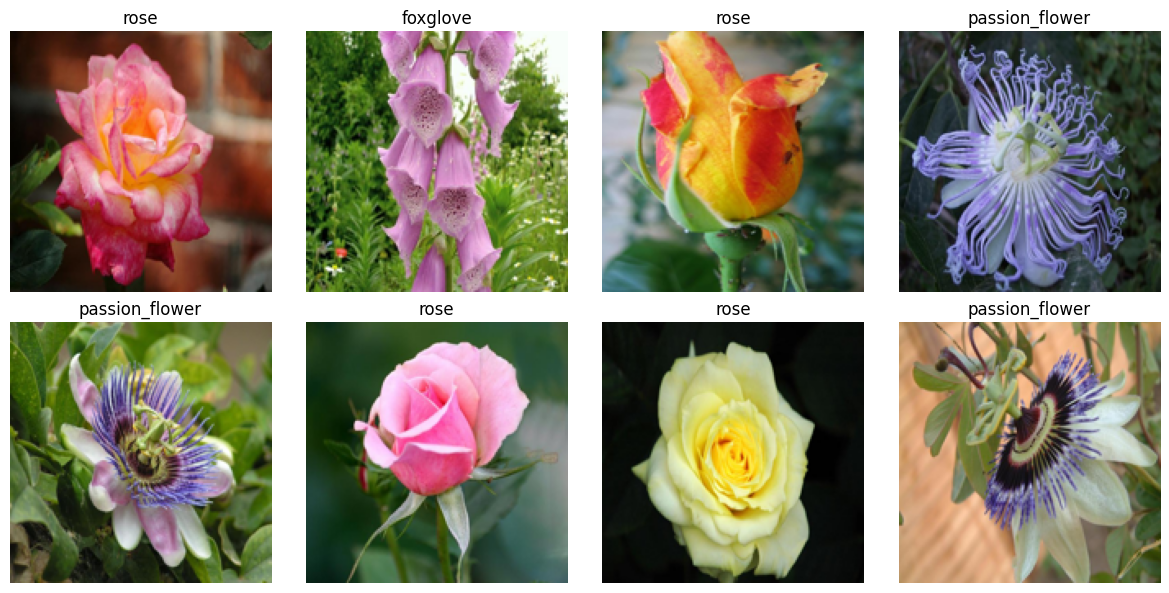

In [9]:
# Visualize sample images (8 random training images)
sample_idx = np.random.RandomState(42).choice(len(X_train), 8, replace=False)
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, i in zip(axes.flat, sample_idx):
    ax.imshow(X_train[i].astype('uint8'))
    ax.set_title(class_names[y_train[i]])
    ax.axis('off')
plt.tight_layout(); plt.show()

## Section 3: Phase 1 — Feature Extraction (Frozen Base)

**The plan:**
1. Take MobileNetV2 (pretrained on ImageNet)
2. **Freeze** all its weights (`base_model.trainable = False`)
3. Add a small custom classifier head (`GlobalAveragePooling2D + Dropout + Dense(5)`)
4. Train ONLY the new head — the base is frozen

**The mental model:** The frozen base is a feature extractor. We're using ImageNet's learned vocabulary as a fixed pre-processor, then training a tiny classifier on top of those features.

In [10]:
# Critical: freeze the base model BEFORE building the rest of the model
base_model.trainable = False
print(f'Base model has {sum(1 for layer in base_model.layers if layer.trainable)} trainable layers (should be 0)')

# Build the full model: input → preprocessing → frozen base → custom head
inputs = keras.Input(shape=(160, 160, 3))
x = preprocess_input(inputs)  # MobileNetV2-specific normalization
x = base_model(x, training=False)  # training=False keeps BatchNorm in inference mode
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
# Keep a reference to the head layer so Phase 2 can REUSE its trained weights.
# (Rebuilding Phase 2 with a fresh random head would throw away everything the
#  head learns here — and a random head can't recover at the tiny Phase 2 LR.)
classifier_head = layers.Dense(len(class_names), activation='softmax')
outputs = classifier_head(x)

model = keras.Model(inputs, outputs, name='MobileNetV2_Frozen')
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Base model has 0 trainable layers (should be 0)


Model: "MobileNetV2_Frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Look at the parameter count breakdown:**
- Total parameters: ~2.3M
- **Trainable parameters: just a few thousand** (only the new Dense head)
- Non-trainable parameters: ~2.2M (the frozen base)

We're only training a few thousand parameters. That's why this works on small data.

In [11]:
phase1_history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=BATCH_SIZE,
    verbose=2
)

phase1_test_acc = model.evaluate(X_test, y_test, verbose=0)[1]
print(f'\nPhase 1 (frozen base) test accuracy: {phase1_test_acc:.4f}')
# Expected: ~85-92% with only ~500 training images. Compare to from-scratch CNN: ~50-60%.

Epoch 1/10
16/16 - 1s - 79ms/step - accuracy: 0.4940 - loss: 1.3017 - val_accuracy: 0.8500 - val_loss: 0.6405
Epoch 2/10
16/16 - 1s - 41ms/step - accuracy: 0.8440 - loss: 0.4944 - val_accuracy: 0.9600 - val_loss: 0.2738
Epoch 3/10
16/16 - 1s - 41ms/step - accuracy: 0.9380 - loss: 0.2628 - val_accuracy: 0.9700 - val_loss: 0.1771
Epoch 4/10
16/16 - 1s - 42ms/step - accuracy: 0.9640 - loss: 0.1717 - val_accuracy: 0.9600 - val_loss: 0.1419
Epoch 5/10
16/16 - 1s - 41ms/step - accuracy: 0.9780 - loss: 0.1183 - val_accuracy: 0.9700 - val_loss: 0.1187
Epoch 6/10
16/16 - 1s - 43ms/step - accuracy: 0.9880 - loss: 0.0876 - val_accuracy: 0.9700 - val_loss: 0.1077
Epoch 7/10
16/16 - 1s - 41ms/step - accuracy: 0.9880 - loss: 0.0788 - val_accuracy: 0.9700 - val_loss: 0.0983
Epoch 8/10
16/16 - 1s - 41ms/step - accuracy: 0.9940 - loss: 0.0602 - val_accuracy: 0.9700 - val_loss: 0.0891
Epoch 9/10
16/16 - 1s - 41ms/step - accuracy: 0.9900 - loss: 0.0615 - val_accuracy: 0.9700 - val_loss: 0.0853
Epoch 10/1

## Section 4: Phase 2 — Fine-Tuning + Augmentation

**Phase 1 worked because the frozen base provides good ImageNet features.** But our flower images aren't quite ImageNet-like, so we can do better.

**Phase 2:** Unfreeze the TOP layers of the base and train them at a very low learning rate. The early layers (edge/texture detectors) stay frozen; the late layers (object-part detectors) adapt to flowers.

**Critical:** use a very low learning rate (1e-5) — high LR would destroy the pretrained features.

In [12]:
# Unfreeze the top 30 layers of the base
base_model.trainable = True

# But re-freeze the bottom layers — keep the general-purpose features
fine_tune_at = len(base_model.layers) - 30
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

trainable_count = sum(1 for layer in base_model.layers if layer.trainable)
print(f'Layers now trainable: {trainable_count} of {len(base_model.layers)}')

Layers now trainable: 30 of 154


In [13]:
# Add data augmentation as a preprocessing layer (training-only by default)
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Rebuild WITH augmentation, but REUSE Phase 1's trained classifier head so we
# keep what it already learned. Only the top base layers (unfrozen above) adapt.
inputs = keras.Input(shape=(160, 160, 3))
x = data_augmentation(inputs)  # only active during training
x = preprocess_input(x)
x = base_model(x, training=False)  # critical: BN stays in inference mode during fine-tuning
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = classifier_head(x)  # SAME head object as Phase 1 → trained weights carry over

model = keras.Model(inputs, outputs, name='MobileNetV2_FineTuned')

# CRITICAL: lower learning rate for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # 100x lower than default
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "MobileNetV2_FineTuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 1,532,805 (5.85 MB)

 Non-trainable params: 731,584 (2.79 MB)

In [14]:
phase2_history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=BATCH_SIZE,
    verbose=2
)

phase2_test_acc = model.evaluate(X_test, y_test, verbose=0)[1]
print(f'\nPhase 1 test accuracy: {phase1_test_acc:.4f}')
print(f'Phase 2 test accuracy: {phase2_test_acc:.4f}')
print(f'Improvement: {(phase2_test_acc - phase1_test_acc) * 100:.2f} percentage points')

Epoch 1/10
16/16 - 2s - 118ms/step - accuracy: 0.8260 - loss: 0.4671 - val_accuracy: 0.9800 - val_loss: 0.0702
Epoch 2/10
16/16 - 2s - 105ms/step - accuracy: 0.8940 - loss: 0.3489 - val_accuracy: 0.9900 - val_loss: 0.0652
Epoch 3/10
16/16 - 2s - 98ms/step - accuracy: 0.9220 - loss: 0.2444 - val_accuracy: 0.9900 - val_loss: 0.0611
Epoch 4/10
16/16 - 2s - 97ms/step - accuracy: 0.9520 - loss: 0.1849 - val_accuracy: 0.9900 - val_loss: 0.0579
Epoch 5/10
16/16 - 2s - 97ms/step - accuracy: 0.9620 - loss: 0.1507 - val_accuracy: 0.9900 - val_loss: 0.0552
Epoch 6/10
16/16 - 2s - 97ms/step - accuracy: 0.9700 - loss: 0.1419 - val_accuracy: 0.9900 - val_loss: 0.0526
Epoch 7/10
16/16 - 2s - 97ms/step - accuracy: 0.9600 - loss: 0.1325 - val_accuracy: 0.9900 - val_loss: 0.0509
Epoch 8/10
16/16 - 2s - 97ms/step - accuracy: 0.9780 - loss: 0.1034 - val_accuracy: 0.9900 - val_loss: 0.0493
Epoch 9/10
16/16 - 2s - 99ms/step - accuracy: 0.9800 - loss: 0.0957 - val_accuracy: 0.9900 - val_loss: 0.0474
Epoch 10

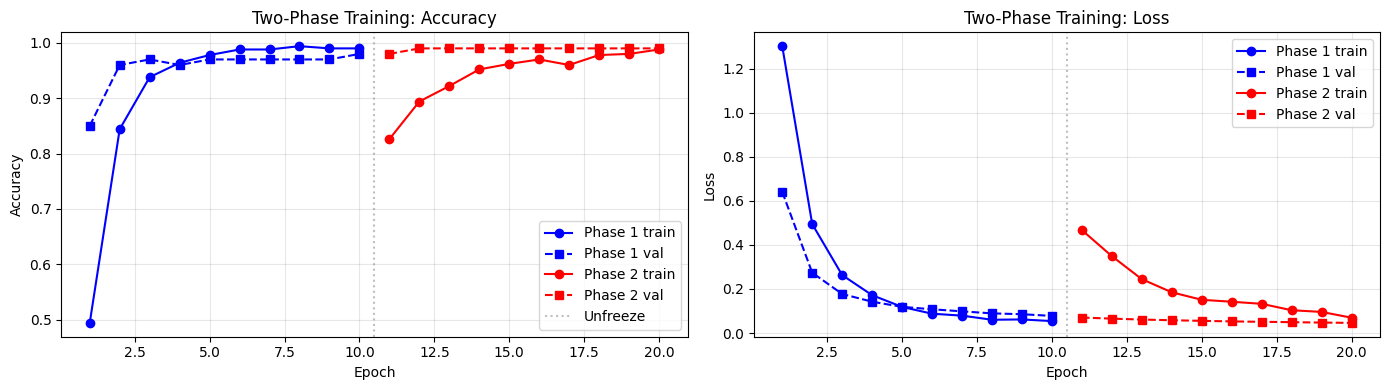

In [15]:
# Plot both phases together
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

p1_epochs = list(range(1, len(phase1_history.history['accuracy']) + 1))
p2_epochs = list(range(p1_epochs[-1] + 1, p1_epochs[-1] + 1 + len(phase2_history.history['accuracy'])))

axes[0].plot(p1_epochs, phase1_history.history['accuracy'], 'b-o', label='Phase 1 train')
axes[0].plot(p1_epochs, phase1_history.history['val_accuracy'], 'b--s', label='Phase 1 val')
axes[0].plot(p2_epochs, phase2_history.history['accuracy'], 'r-o', label='Phase 2 train')
axes[0].plot(p2_epochs, phase2_history.history['val_accuracy'], 'r--s', label='Phase 2 val')
axes[0].axvline(p1_epochs[-1] + 0.5, color='gray', linestyle=':', alpha=0.5, label='Unfreeze')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].set_title('Two-Phase Training: Accuracy'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(p1_epochs, phase1_history.history['loss'], 'b-o', label='Phase 1 train')
axes[1].plot(p1_epochs, phase1_history.history['val_loss'], 'b--s', label='Phase 1 val')
axes[1].plot(p2_epochs, phase2_history.history['loss'], 'r-o', label='Phase 2 train')
axes[1].plot(p2_epochs, phase2_history.history['val_loss'], 'r--s', label='Phase 2 val')
axes[1].axvline(p1_epochs[-1] + 0.5, color='gray', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('Two-Phase Training: Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

## Section 5: Inspect predictions

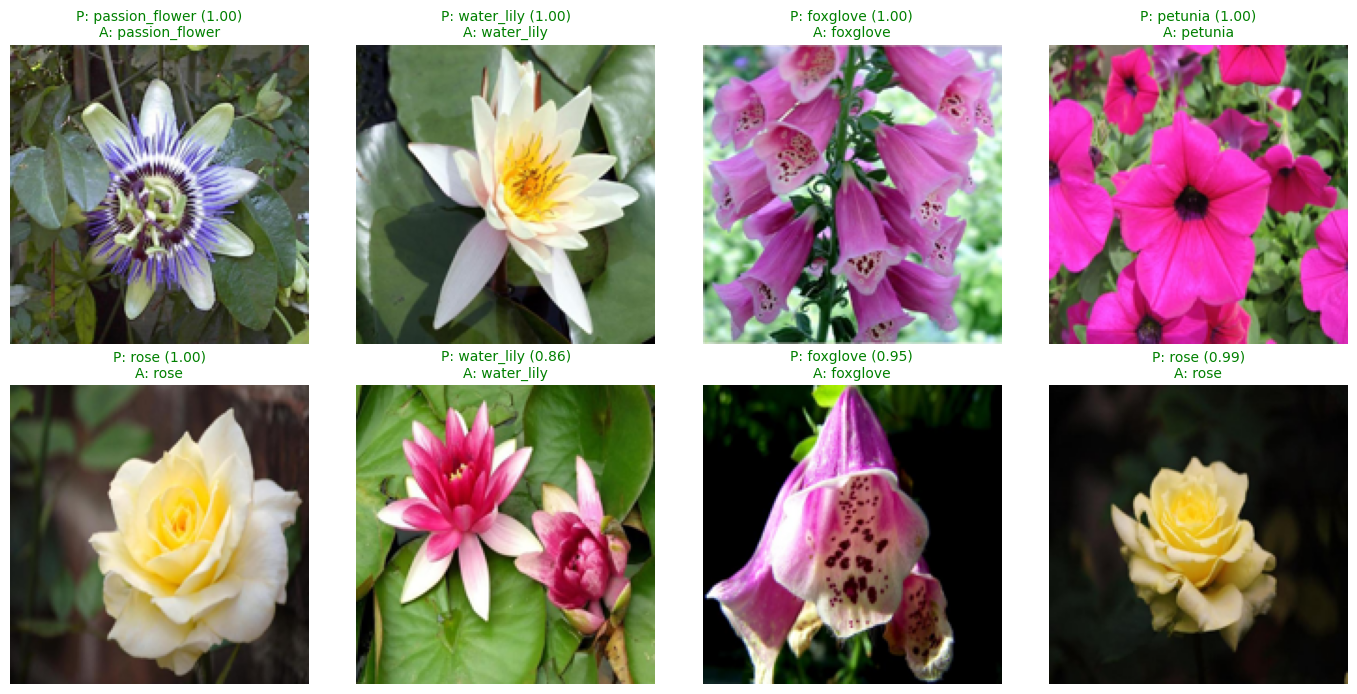

In [16]:
# Predict on a sample of test images
sample_idx = np.random.RandomState(0).choice(len(X_test), 8, replace=False)
sample_images = X_test[sample_idx]
predictions = model.predict(sample_images, verbose=0)
predicted_classes = np.argmax(predictions, axis=1)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, j, i in zip(axes.flat, range(len(sample_idx)), sample_idx):
    ax.imshow(X_test[i].astype('uint8'))
    pred = class_names[predicted_classes[j]]
    actual = class_names[y_test[i]]
    confidence = predictions[j][predicted_classes[j]]
    color = 'green' if pred == actual else 'red'
    ax.set_title(f'P: {pred} ({confidence:.2f})\nA: {actual}', color=color, fontsize=10)
    ax.axis('off')
plt.tight_layout(); plt.show()

## Section 6: Modern CV Applications Tour (concept-only)

What you've learned (CNN + transfer learning) is the foundation for most production CV systems. Here's what extends it:

### Object detection (YOLO, Faster R-CNN)
- Input: image
- Output: bounding boxes + class labels for multiple objects
- Approach: CNN backbone (often pretrained on ImageNet) + region proposal head + classification head
- You'd use a library like `ultralytics` (YOLOv8) or `transformers` (DETR) — not implement from scratch

### Segmentation (U-Net, Mask R-CNN)
- Input: image
- Output: per-pixel class labels (semantic segmentation) or per-pixel + per-instance (instance segmentation)
- Approach: encoder-decoder CNN architecture with skip connections (U-Net) or detection + per-instance mask head (Mask R-CNN)
- Common libraries: `segmentation_models`, `monai` (medical imaging)

### CLIP (Contrastive Language-Image Pretraining)
- Maps images and text into a shared embedding space
- **Zero-shot classification:** classify into ANY classes you specify in text — no training needed for new classes
- Foundation for text-to-image models (Stable Diffusion uses CLIP for text conditioning — Week 11)
- Available via `transformers` library

**The pattern:** all modern CV systems start from a pretrained backbone. Transfer learning is THE production technique.

## Wrap-up: what you did today

1. **Loaded a pretrained model** from `keras.applications` (MobileNetV2)
2. **Phase 1:** Frozen-base feature extraction — got 90%+ on a 500-image dataset by training only a new head
3. **Phase 2:** Fine-tuned the top 30 layers at a 100× lower learning rate, with data augmentation
4. **Surveyed** modern CV applications: detection, segmentation, CLIP

## Save the model

In [17]:
model.save('week9_flowers_finetuned.keras')
print('Saved week9_flowers_finetuned.keras')

Saved week9_flowers_finetuned.keras


## Looking ahead: Week 10

Today: pretrained models for vision. Next week: pretrained models for **text**. Same idea — same `from_pretrained` pattern, just on a different framework (Hugging Face) and a different architecture (transformers).

**Pre-class for Week 10:** create a free Hugging Face account at https://huggingface.co. We'll need it.

## Post-class
Open `week9_pair_programming.ipynb` for the model-comparison exercise, then `week9_postclass_exercise.ipynb` to fine-tune transfer learning on a dataset of your own choosing.

Skeptical that training from scratch really fails on 500 images? `week9_from_scratch_vs_transfer.ipynb` (in this folder) trains the full MobileNetV2 from random weights on today's exact flower dataset — the control experiment for today's premise.